In [1]:
import torch
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)
use_cuda = torch.cuda.is_available()
print(use_cuda)

Sun Jun  7 01:37:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090      WDDM  |   00000000:01:00.0  On |                  N/A |
| 35%   46C    P8             27W /  350W |    7161MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
SEED = 42
WEIGHTED = True

In [3]:
from datasets import *
import pandas as pd
import numpy as np
train = pd.DataFrame(load_dataset("public_data/train/track_a/eng", split="train"))
bias_AC=[]
bias_DI=[]
bias_ANB=[]
for i in range(len(train)):
    bias_AC.append(int(train['bias_labels'][i][1]))
    bias_DI.append(int(train['bias_labels'][i][4]))
    bias_ANB.append(int(train['bias_labels'][i][7]))
train['bias_AC']=bias_AC
train['bias_DI']=bias_DI
train['bias_ANB']=bias_ANB
train.head()

D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,ori_sentence,bias_labels,bias_AC,bias_DI,bias_ANB
0,史更新从来也没有遇到过这样的绝境，从来也没有感到过这样没有办法，平常时候他能够跨过高山，凫过...,"[0, 1, 0]",0,1,0
1,“怎么个请法？”红菱的大脚指头勾动一下，又淘气又下贱。,"[0, 1, 1]",0,1,1
2,这不是我的下贱，可能是我的卑鄙，我幻想着如果他在那一刻真的认为我就是你，也许他会让我有孩子的。,"[0, 1, 0]",0,1,0
3,候，我会记着你的。记着你！是的，我要从我的记忆的碑版上，拭去一切琐碎愚蠢的记录、一切书本上的...,"[1, 0, 0]",1,0,0
4,外场劲儿，半恼半笑，假装不甚在乎的样子打了句哈哈：“你可倒好！肉包子打狗，一去不回头啊！”她...,"[1, 1, 0]",1,1,0


In [4]:
labels = ["bias_AC", "bias_DI", "bias_ANB"]
def get_text_and_label(df):
  return df.rename(columns={"ori_sentence": "ori_sentence"})[["ori_sentence"] + labels]
train = get_text_and_label(train)
val = get_text_and_label(train)
test = get_text_and_label(train)
print(f"Dataset size: <{len(train.index)}:{len(val.index)}:{len(test.index)}>")
train.head(10)

Dataset size: <25590:25590:25590>


,ori_sentence,bias_AC,bias_DI,bias_ANB
0,史更新从来也没有遇到过这样的绝境，从来也没有感到过这样没有办法，平常时候他能够跨过高山，凫过...,0,1,0
1,“怎么个请法？”红菱的大脚指头勾动一下，又淘气又下贱。,0,1,1
2,这不是我的下贱，可能是我的卑鄙，我幻想着如果他在那一刻真的认为我就是你，也许他会让我有孩子的。,0,1,0
3,候，我会记着你的。记着你！是的，我要从我的记忆的碑版上，拭去一切琐碎愚蠢的记录、一切书本上的...,1,0,0
4,外场劲儿，半恼半笑，假装不甚在乎的样子打了句哈哈：“你可倒好！肉包子打狗，一去不回头啊！”她...,1,1,0
5,懂什么叫爱情，不懂你说的那个爱情。他对你，是不是跟你待他的心肠一样呢？”“我不知道，我不知道...,0,1,0
6,流苏在那里看她，她也昂然望着流苏，那一双骄矜的眼睛，如同隔着几千里地，远远的向人望过来。,0,1,0
7,这思想开始火焰似的把她燃烧起来了，她再也克制不住自己了，骄傲，自尊，虚荣，矜持……全都冰消瓦解了。,0,1,0
8,门岗的小兵说：“没有借书证我不会放你们进去，走吧走吧。”李淡云十五岁了，已懂得拿眉梢眼角去搔...,0,1,0
9,愧，连连责骂自己的不成熟：美什么美？可不是应该的？和那些福童比起来，你已经晚了。这么骂着、怨...,0,1,0


In [5]:
def generate_multilabel_df(df):
  df["bias_labels"] = np.empty((len(df), len(labels))).tolist()
  for index, row in df.iterrows():
    row_labels = [row[label] for label in labels]
    for i in range(len(labels)):
      df.loc[index, "bias_labels"][i] = row_labels[i]
  return df[["ori_sentence", "bias_labels"]]
train = generate_multilabel_df(train)
val = generate_multilabel_df(val)
test = generate_multilabel_df(test)
train.head(10)

,ori_sentence,bias_labels
0,史更新从来也没有遇到过这样的绝境，从来也没有感到过这样没有办法，平常时候他能够跨过高山，凫过...,"[0, 1, 0]"
1,“怎么个请法？”红菱的大脚指头勾动一下，又淘气又下贱。,"[0, 1, 1]"
2,这不是我的下贱，可能是我的卑鄙，我幻想着如果他在那一刻真的认为我就是你，也许他会让我有孩子的。,"[0, 1, 0]"
3,候，我会记着你的。记着你！是的，我要从我的记忆的碑版上，拭去一切琐碎愚蠢的记录、一切书本上的...,"[1, 0, 0]"
4,外场劲儿，半恼半笑，假装不甚在乎的样子打了句哈哈：“你可倒好！肉包子打狗，一去不回头啊！”她...,"[1, 1, 0]"
5,懂什么叫爱情，不懂你说的那个爱情。他对你，是不是跟你待他的心肠一样呢？”“我不知道，我不知道...,"[0, 1, 0]"
6,流苏在那里看她，她也昂然望着流苏，那一双骄矜的眼睛，如同隔着几千里地，远远的向人望过来。,"[0, 1, 0]"
7,这思想开始火焰似的把她燃烧起来了，她再也克制不住自己了，骄傲，自尊，虚荣，矜持……全都冰消瓦解了。,"[0, 1, 0]"
8,门岗的小兵说：“没有借书证我不会放你们进去，走吧走吧。”李淡云十五岁了，已懂得拿眉梢眼角去搔...,"[0, 1, 0]"
9,愧，连连责骂自己的不成熟：美什么美？可不是应该的？和那些福童比起来，你已经晚了。这么骂着、怨...,"[0, 1, 0]"


In [7]:
from simpletransformers.classification import MultiLabelClassificationModel, MultiLabelClassificationArgs
model_args = MultiLabelClassificationArgs(
    overwrite_output_dir= True,
    eval_batch_size=8,
    # num_train_epochs=5,
    num_train_epochs=1,
    learning_rate = 4e-05,
    optimizer="AdamW",
    manual_seed=SEED,
    use_early_stopping=True,
)

In [8]:
models = {
    "bert-cased": MultiLabelClassificationModel("bert", 'models--Geotrend--bert-base-zh-cased', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    "ernie-base": MultiLabelClassificationModel("bert", 'models--nghuyong--ernie-1.0-base-zh', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    "roberta-chinese": MultiLabelClassificationModel("bert", 'models--hongyin--roberta-chinese-homie-large', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    "roberta-chinese-large": MultiLabelClassificationModel("bert", 'models--clue--roberta_chinese_large', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    # "beto-uncased": MultiLabelClassificationModel("bert", 'models--dccuchile--bert-base-spanish-wwm-uncased', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    # "distilbert-multi": MultiLabelClassificationModel("distilbert", 'models--distilbert--distilbert-base-multilingual-cased', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
}

Some weights of BertForMultiLabelSequenceClassification were not initialized from the model checkpoint at models--Geotrend--bert-base-zh-cased and are newly initialized: ['classifier.bias', 'bert.pooler.dense.weight', 'classifier.weight', 'bert.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You are using a model of type ernie to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of BertForMultiLabelSequenceClassification were not initialized from the model checkpoint at models--nghuyong--ernie-1.0-base-zh and are newly initialized: ['encoder.layer.6.attention.self.value.weight', 'encoder.layer.3.output.dense.bias', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.2.output.dense.weight', 'encoder.layer.2.attention.self.query.bias', 'encoder.layer.10.output.LayerNorm.weight', 'encoder.layer.8.output.dense.bias', 'encoder.lay

In [9]:
from sklearn.metrics import mean_squared_error
from math import sqrt
def root_mean_squared_error(y_true, y_pred):    
    return sqrt(mean_squared_error(y_true, y_pred))

In [ ]:
for model_name, model in models.items():
  model.train_model(train, loss_fct=root_mean_squared_error)

C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:610: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(
52it [00:17,  3.04it/s]                                                                                                                                                                                                                   
Epochs 1/1. Running Loss:    0.2313:  41%|████████████████████████████████████████████████████████████████▏                                                                                           | 1316/3199 [01:23<01:58, 15.94it/s]
52it [00:17,  2.89it/s]                                                                                                                                                                                                                   
Epochs 1/1. Running Loss: 

In [11]:
import collections
from itertools import combinations
models_names = list(models.keys())
ensembles_list = list()
for i in range(1, len(models_names) + 1):
    ensembles_list += list(combinations(models_names, i))
ensembles_list = [list(ensemble) for ensemble in ensembles_list]
ensembles = {}
for i in range(len(ensembles_list)):
  ensembles["ensemble{:02d}".format(i)] = {}
  ensembles["ensemble{:02d}".format(i)]["models"] = ensembles_list[i]
  ensembles["ensemble{:02d}".format(i)]["metrics"] = {}
ensembles

{'ensemble00': {'models': ['bert-cased'], 'metrics': {}},
 'ensemble01': {'models': ['ernie-base'], 'metrics': {}},
 'ensemble02': {'models': ['roberta-chinese'], 'metrics': {}},
 'ensemble03': {'models': ['roberta-chinese-large'], 'metrics': {}},
 'ensemble04': {'models': ['bert-cased', 'ernie-base'], 'metrics': {}},
 'ensemble05': {'models': ['bert-cased', 'roberta-chinese'], 'metrics': {}},
 'ensemble06': {'models': ['bert-cased', 'roberta-chinese-large'],
  'metrics': {}},
 'ensemble07': {'models': ['ernie-base', 'roberta-chinese'], 'metrics': {}},
 'ensemble08': {'models': ['ernie-base', 'roberta-chinese-large'],
  'metrics': {}},
 'ensemble09': {'models': ['roberta-chinese', 'roberta-chinese-large'],
  'metrics': {}},
 'ensemble10': {'models': ['bert-cased', 'ernie-base', 'roberta-chinese'],
  'metrics': {}},
 'ensemble11': {'models': ['bert-cased',
   'ernie-base',
   'roberta-chinese-large'],
  'metrics': {}},
 'ensemble12': {'models': ['bert-cased',
   'roberta-chinese',
   'r

In [12]:
from datasets import *
import pandas as pd
import numpy as np
val = pd.DataFrame(load_dataset("public_data/train/track_a/eng_val", split="validation"))
bias_AC=[]
bias_DI=[]
bias_ANB=[]
for i in range(len(val)):
    bias_AC.append(int(val['bias_labels'][i][1]))
    bias_DI.append(int(val['bias_labels'][i][4]))
    bias_ANB.append(int(val['bias_labels'][i][7]))
val['bias_AC']=bias_AC
val['bias_DI']=bias_DI
val['bias_ANB']=bias_ANB
val.head()

Generating validation split: 1032 examples [00:00, 40668.98 examples/s]


,ori_sentence,bias_labels,bias_AC,bias_DI,bias_ANB
0,那时候东山依然在使着眼色，可他的新娘因为无法理解而脸上布满了愚蠢。于是东山便凑过去咬牙切齿地...,"[0, 1, 0]",0,1,0
1,下贱东西，大约她知道自己太不行，必须找个比她再下贱的。,"[0, 1, 0]",0,1,0
2,胡文玉不只生的魁伟俊秀，而且工作上有魄力，有办法，写得一手好文章，讲起话来又头头是道。,"[0, 1, 0]",0,1,0
3,雷斯林恼怒的甩开手。面无表情的伸出手，抓住她纤弱的白饱。他猛然一扯，将衣服给扯了下来，另一只...,"[1, 1, 0]",1,1,0
4,她向他偷递了一个眼色。似乎她与克里斯有个秘密的共谋，她在提醒他别忘了。抑或，她和他都不清楚那...,"[0, 1, 0]",0,1,0


In [13]:
labels = ["bias_AC", "bias_DI", "bias_ANB"]
def get_text_and_label(df):
  return df.rename(columns={"ori_sentence": "ori_sentence"})[["ori_sentence"] + labels]
val = get_text_and_label(val)
test = get_text_and_label(val)
print(f"Dataset size: <{len(train.index)}:{len(val.index)}:{len(test.index)}>")
val.head(10)

Dataset size: <25590:1032:1032>


,ori_sentence,bias_AC,bias_DI,bias_ANB
0,那时候东山依然在使着眼色，可他的新娘因为无法理解而脸上布满了愚蠢。于是东山便凑过去咬牙切齿地...,0,1,0
1,下贱东西，大约她知道自己太不行，必须找个比她再下贱的。,0,1,0
2,胡文玉不只生的魁伟俊秀，而且工作上有魄力，有办法，写得一手好文章，讲起话来又头头是道。,0,1,0
3,雷斯林恼怒的甩开手。面无表情的伸出手，抓住她纤弱的白饱。他猛然一扯，将衣服给扯了下来，另一只...,1,1,0
4,她向他偷递了一个眼色。似乎她与克里斯有个秘密的共谋，她在提醒他别忘了。抑或，她和他都不清楚那...,0,1,0
5,"的,但她拒绝了罗伯特的求婚).斯黛拉曾不断被人们认为是她那代人的典型,那一代人又常常被描述成...",1,0,0
6,她就像是精灵与神仙的混合体，兼有了妖娆与神圣两种迥然不同的气质，却又非常调和地出现在她身上。,0,1,0
7,她的妖娆的姿态，她的锋利的谈吐。,0,1,0
8,但是今天，他却忽然想，他有什么必要必须鼓起这种耐心呢？小敏发脾气的样子他曾经觉得另有一种味儿...,0,1,1
9,她年纪已经过了三十，渐渐发胖了，在黑纱衫里闪烁着老粗的金链条，嘴唇红得悍然，浑身熟极而流的扭...,0,1,0


In [14]:
def generate_multilabel_df(df):
  df["bias_labels"] = np.empty((len(df), len(labels))).tolist()
  for index, row in df.iterrows():
    row_labels = [row[label] for label in labels]
    for i in range(len(labels)):
      df.loc[index, "bias_labels"][i] = row_labels[i]
  return df[["ori_sentence", "bias_labels"]]
val = generate_multilabel_df(val)
test = generate_multilabel_df(test)
val.head(10)

,ori_sentence,bias_labels
0,那时候东山依然在使着眼色，可他的新娘因为无法理解而脸上布满了愚蠢。于是东山便凑过去咬牙切齿地...,"[0, 1, 0]"
1,下贱东西，大约她知道自己太不行，必须找个比她再下贱的。,"[0, 1, 0]"
2,胡文玉不只生的魁伟俊秀，而且工作上有魄力，有办法，写得一手好文章，讲起话来又头头是道。,"[0, 1, 0]"
3,雷斯林恼怒的甩开手。面无表情的伸出手，抓住她纤弱的白饱。他猛然一扯，将衣服给扯了下来，另一只...,"[1, 1, 0]"
4,她向他偷递了一个眼色。似乎她与克里斯有个秘密的共谋，她在提醒他别忘了。抑或，她和他都不清楚那...,"[0, 1, 0]"
5,"的,但她拒绝了罗伯特的求婚).斯黛拉曾不断被人们认为是她那代人的典型,那一代人又常常被描述成...","[1, 0, 0]"
6,她就像是精灵与神仙的混合体，兼有了妖娆与神圣两种迥然不同的气质，却又非常调和地出现在她身上。,"[0, 1, 0]"
7,她的妖娆的姿态，她的锋利的谈吐。,"[0, 1, 0]"
8,但是今天，他却忽然想，他有什么必要必须鼓起这种耐心呢？小敏发脾气的样子他曾经觉得另有一种味儿...,"[0, 1, 1]"
9,她年纪已经过了三十，渐渐发胖了，在黑纱衫里闪烁着老粗的金链条，嘴唇红得悍然，浑身熟极而流的扭...,"[0, 1, 0]"


In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
def compute_metrics(y_true, y_pred):
  macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
  acc = accuracy_score(y_true, y_pred)
  weighted_f1 = f1_score(y_true, y_pred, average='weighted')  
  return {      
    'accuracy': round(acc, 5),      
    'macro_f1': round(macro_f1, 5),      
    'macro_precision': round(macro_precision, 5),      
    'macro_recall': round(macro_recall, 5),      
    'weighted_f1': round(weighted_f1, 5)  
  }
model_evaluation = {}
for model_name in models:
  model_evaluation[model_name] = {}  
  result, model_outputs, wrong_predictions = models[model_name].eval_model(val, metric=root_mean_squared_error)
  model_evaluation[model_name]["result"] = result                                                                   
  model_evaluation[model_name]["val_model_outputs"] = model_outputs                                                
  model_evaluation[model_name]["val_predictions"] = list ()  
  for output in model_outputs:
    model_evaluation[model_name]["val_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output]) 
  model_evaluation[model_name]["val_wrong_predictions"] = wrong_predictions                                          
  model_evaluation[model_name]["metrics"] = compute_metrics(val.get("bias_labels").tolist(), model_evaluation[model_name].get("val_predictions"))  
  print(f"{model_name}\t", model_evaluation[model_name].get("metrics"))

C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(
3it [00:03,  1.03s/it]                                                                                                                                                                                                                    
Running Evaluation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [00:02<00:00, 54.53it/s]
C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warni

bert-cased	 {'accuracy': 0.53585, 'macro_f1': 0.2701, 'macro_precision': 0.46676, 'macro_recall': 0.21519, 'weighted_f1': 0.23306}


3it [00:02,  1.06it/s]                                                                                                                                                                                                                    
Running Evaluation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [00:02<00:00, 56.30it/s]
D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to 

ernie-base	 {'accuracy': 0.52713, 'macro_f1': 0.24535, 'macro_precision': 0.35393, 'macro_recall': 0.18779, 'weighted_f1': 0.20955}


3it [00:02,  1.08it/s]                                                                                                                                                                                                                    
Running Evaluation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [00:04<00:00, 30.91it/s]
D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to 

roberta-chinese	 {'accuracy': 0.50194, 'macro_f1': 0.0, 'macro_precision': 0.0, 'macro_recall': 0.0, 'weighted_f1': 0.0}


3it [00:02,  1.00it/s]                                                                                                                                                                                                                    
Running Evaluation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [00:04<00:00, 30.91it/s]


roberta-chinese-large	 {'accuracy': 0.5407, 'macro_f1': 0.33226, 'macro_precision': 0.55776, 'macro_recall': 0.24338, 'weighted_f1': 0.31026}


In [16]:
from sklearn.preprocessing import normalize
def vote(predictions, weighted=False, weights=None):
  votes = list()  
  for i in range(len(labels)):    
    curr_label_preds = [preds[i] for preds in predictions]    
    voting = sum(curr_label_preds * weights) if weighted else sum(curr_label_preds)/len(curr_label_preds)
    votes.append(0 if voting < 0.5 else 1)  
  return votes
ensemble_evaluation = {}
def predict_ensemble(ensemble_name, dataset_name, dataset, weighted=False):
  ensemble_evaluation[ensemble_name][f"{dataset_name}_predictions"] = list()  
  for i in range(len(dataset.index)):
    predictions = list()
    ensemble_models = ensembles[ensemble_name].get("models")      
    for model_name in ensemble_models:
      curr_model_outputs = model_evaluation[model_name].get(f"{dataset_name}_model_outputs")
      predictions.append(curr_model_outputs[i])
    weights = list()    
    if weighted:      
      f1_scores_list = [model_evaluation[model_name]["metrics"].get("weighted_f1")                        
                        for model_name in ensembles[ensemble_name].get("models")]
      weights = normalize([f1_scores_list], norm="l1")[0]
    ensemble_pred = vote(predictions, weighted, weights)
    ensemble_evaluation[ensemble_name][f"{dataset_name}_predictions"].append(ensemble_pred)
for ensemble_name in ensembles:
  ensemble_evaluation[ensemble_name] = {}
  ensemble_evaluation[ensemble_name]["val_predictions"] = list()
  predict_ensemble(ensemble_name, "val", val, weighted=WEIGHTED)
  ensembles[ensemble_name]["metrics"] = compute_metrics(val.get("bias_labels").tolist(), ensemble_evaluation[ensemble_name].get("val_predictions"))  
  print(f"{ensemble_name}\t", ensembles[ensemble_name].get("metrics"))

ensemble00	 {'accuracy': 0.53585, 'macro_f1': 0.2701, 'macro_precision': 0.46676, 'macro_recall': 0.21519, 'weighted_f1': 0.23306}


D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ensemble01	 {'accuracy': 0.52713, 'macro_f1': 0.24535, 'macro_precision': 0.35393, 'macro_recall': 0.18779, 'weighted_f1': 0.20955}


D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ensemble02	 {'accuracy': 0.50194, 'macro_f1': 0.0, 'macro_precision': 0.0, 'macro_recall': 0.0, 'weighted_f1': 0.0}
ensemble03	 {'accuracy': 0.5407, 'macro_f1': 0.33226, 'macro_precision': 0.55776, 'macro_recall': 0.24338, 'weighted_f1': 0.31026}


...

D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ensemble11	 {'accuracy': 0.52519, 'macro_f1': 0.25218, 'macro_precision': 0.39998, 'macro_recall': 0.18498, 'weighted_f1': 0.21615}
ensemble12	 {'accuracy': 0.54167, 'macro_f1': 0.31347, 'macro_precision': 0.57825, 'macro_recall': 0.22603, 'weighted_f1': 0.28786}


D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ensemble13	 {'accuracy': 0.52229, 'macro_f1': 0.24833, 'macro_precision': 0.40785, 'macro_recall': 0.17863, 'weighted_f1': 0.21255}
ensemble14	 {'accuracy': 0.52519, 'macro_f1': 0.25218, 'macro_precision': 0.39998, 'macro_recall': 0.18498, 'weighted_f1': 0.21615}


D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [17]:
f1_scores = {ensemble_name: ensembles[ensemble_name]["metrics"].get("weighted_f1") for ensemble_name in ensemble_evaluation}
best_ensemble_name = max(f1_scores, key=f1_scores.get)
best_ensemble = {"name": best_ensemble_name,                 
"models": ensembles[best_ensemble_name].get("models"),                 
"metrics": ensembles[best_ensemble_name].get("metrics")                 
}
best_ensemble

{'name': 'ensemble03',
 'models': ['roberta-chinese-large'],
 'metrics': {'accuracy': 0.5407,
  'macro_f1': 0.33226,
  'macro_precision': 0.55776,
  'macro_recall': 0.24338,
  'weighted_f1': 0.31026}}

In [18]:
for model_name in best_ensemble.get("models"):
  model_predictions, model_raw_outputs = models.get(model_name).predict(test["ori_sentence"].tolist())
  model_evaluation[model_name]["test_model_outputs"] = model_raw_outputs
  model_evaluation[model_name]["test_predictions"] = list ()  
  for output in model_raw_outputs:
    model_evaluation[model_name]["test_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output])
predict_ensemble(best_ensemble.get("name"), "test", test, weighted=WEIGHTED)

3it [00:02,  1.05it/s]                                                                                                                                                                                                                    
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [00:04<00:00, 28.95it/s]


In [19]:
test["predicted_labels"] = ensemble_evaluation[best_ensemble.get("name")].get("test_predictions")
test.head(30)

,ori_sentence,bias_labels,predicted_labels
0,那时候东山依然在使着眼色，可他的新娘因为无法理解而脸上布满了愚蠢。于是东山便凑过去咬牙切齿地...,"[0, 1, 0]","[0, 1, 0]"
1,下贱东西，大约她知道自己太不行，必须找个比她再下贱的。,"[0, 1, 0]","[0, 0, 0]"
2,胡文玉不只生的魁伟俊秀，而且工作上有魄力，有办法，写得一手好文章，讲起话来又头头是道。,"[0, 1, 0]","[0, 0, 0]"
3,雷斯林恼怒的甩开手。面无表情的伸出手，抓住她纤弱的白饱。他猛然一扯，将衣服给扯了下来，另一只...,"[1, 1, 0]","[0, 0, 0]"
4,她向他偷递了一个眼色。似乎她与克里斯有个秘密的共谋，她在提醒他别忘了。抑或，她和他都不清楚那...,"[0, 1, 0]","[0, 0, 0]"
5,"的,但她拒绝了罗伯特的求婚).斯黛拉曾不断被人们认为是她那代人的典型,那一代人又常常被描述成...","[1, 0, 0]","[0, 0, 0]"
6,她就像是精灵与神仙的混合体，兼有了妖娆与神圣两种迥然不同的气质，却又非常调和地出现在她身上。,"[0, 1, 0]","[0, 0, 0]"
7,她的妖娆的姿态，她的锋利的谈吐。,"[0, 1, 0]","[0, 1, 0]"
8,但是今天，他却忽然想，他有什么必要必须鼓起这种耐心呢？小敏发脾气的样子他曾经觉得另有一种味儿...,"[0, 1, 1]","[0, 0, 0]"
9,她年纪已经过了三十，渐渐发胖了，在黑纱衫里闪烁着老粗的金链条，嘴唇红得悍然，浑身熟极而流的扭...,"[0, 1, 0]","[0, 0, 0]"


In [20]:
from sklearn.metrics import classification_report
cr = classification_report(y_true=test["bias_labels"].tolist(), y_pred=test["predicted_labels"].tolist(), target_names=labels)
print(cr)

              precision    recall  f1-score   support

     bias_AC       0.50      0.12      0.19       281
     bias_DI       0.75      0.39      0.51       182
    bias_ANB       0.43      0.22      0.29       210

   micro avg       0.56      0.22      0.32       673
   macro avg       0.56      0.24      0.33       673
weighted avg       0.54      0.22      0.31       673
 samples avg       0.12      0.09      0.10       673



D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


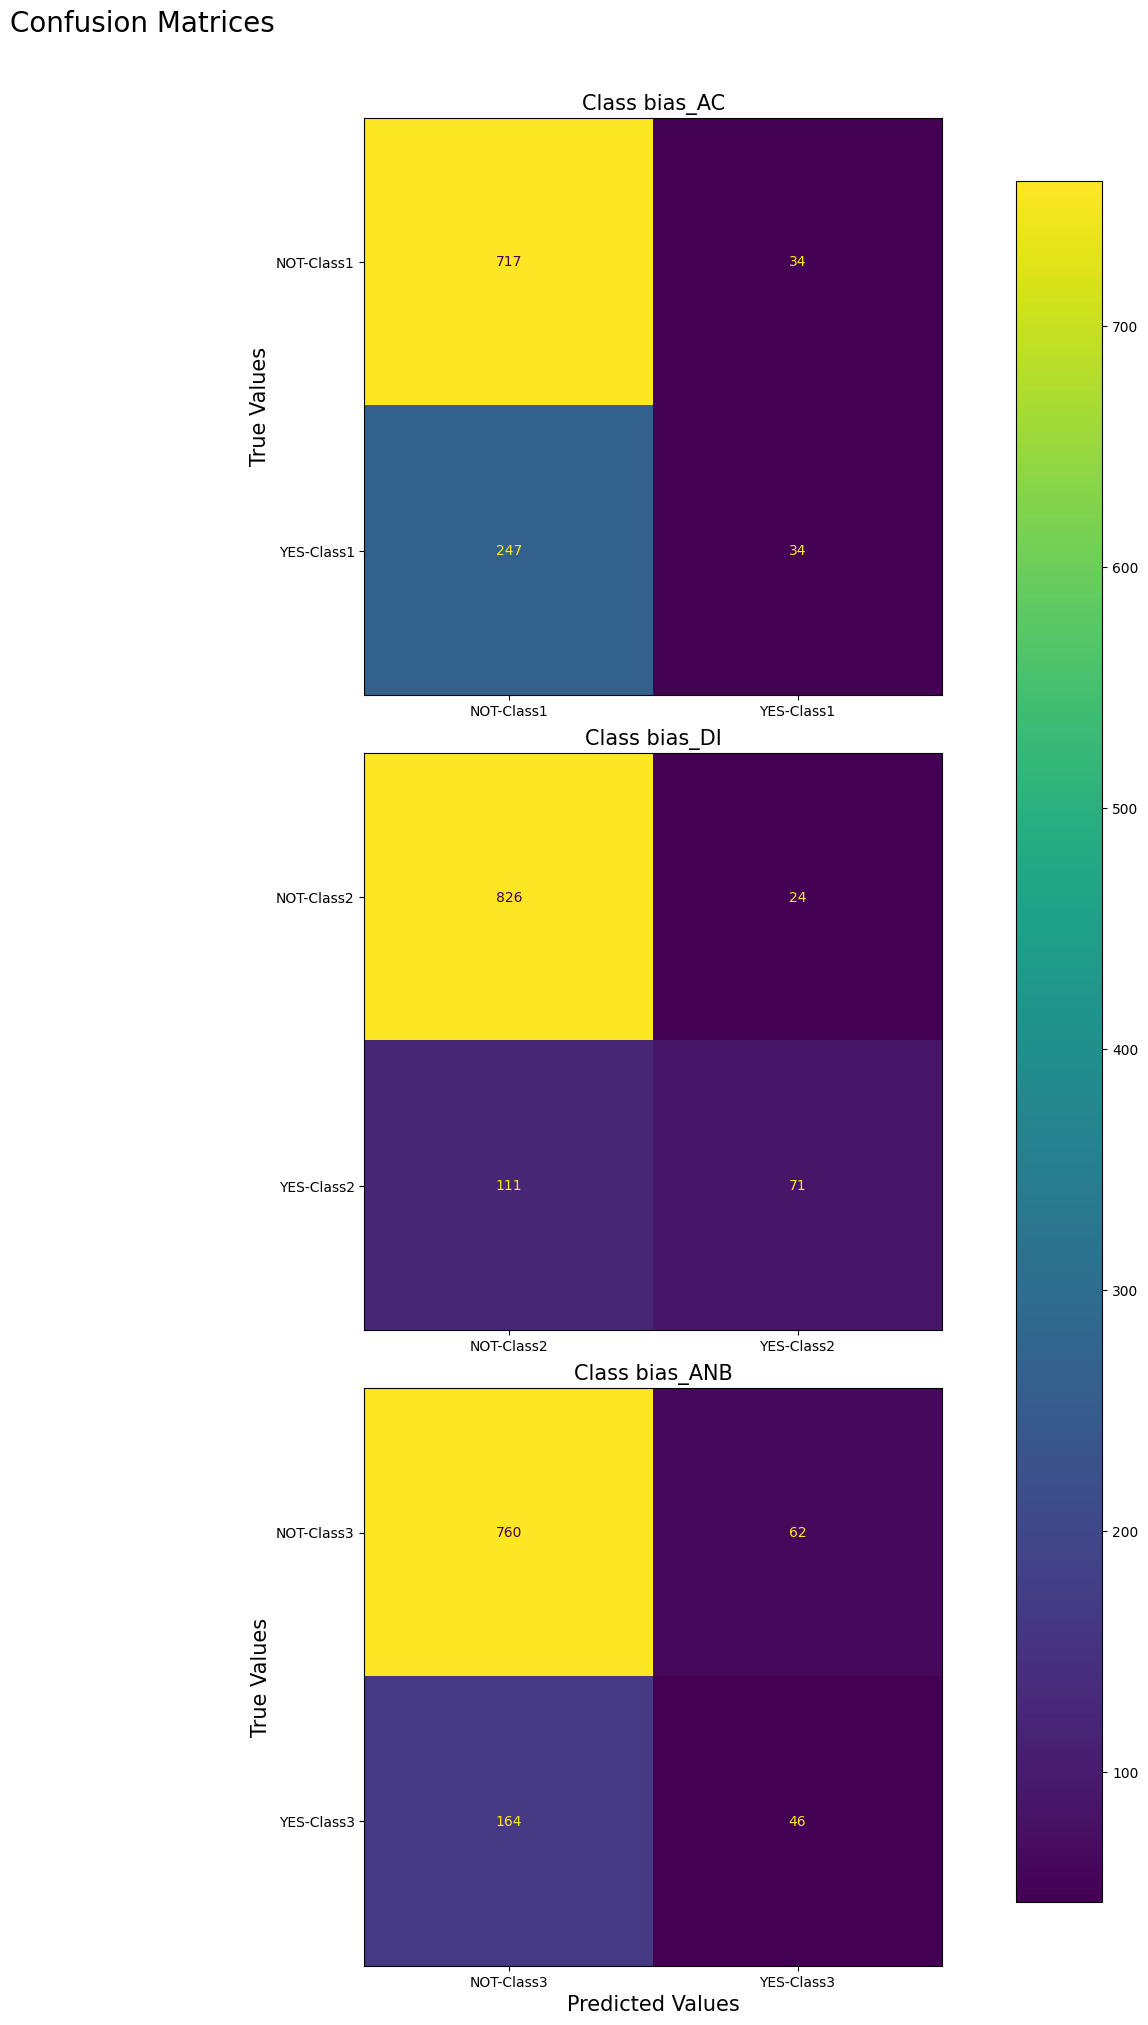

In [21]:
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(24, 24))
axes = axes.ravel()
for i in range(len(labels)):
  y_true = [label[i] for label in test["bias_labels"].tolist()]
  y_pred = [label[i] for label in test["predicted_labels"].tolist()]
  disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=[f"NOT-Class{i+1}", f"YES-Class{i+1}"])
  disp.plot(ax=axes[i], values_format='.4g')
  disp.ax_.set_title("Class {}".format(labels[i]), fontsize=15)  
  if i<2:
    disp.ax_.set_xlabel('')  
  else:
    disp.ax_.set_xlabel('Predicted Values', fontsize=15)  
  if i%2!=0:
    disp.ax_.set_ylabel('')  
  else:
    disp.ax_.set_ylabel('True Values', fontsize=15)
  disp.im_.colorbar.remove()
plt.subplots_adjust(wspace=0.25, hspace=0.1)
fig.colorbar(disp.im_, ax=axes, fraction=0.04625, pad=0.04)
plt.suptitle("Confusion Matrices", fontsize=20, y=0.925)
plt.show()

C:\Users\wangkongqiang\AppData\Local\Temp\ipykernel_4076\539791059.py:8: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], "k--", color = "darkblue", linestyle = "--", label = "Random Classifier (AUC = 0.5)") # AUC: Area Under Curve
C:\Users\wangkongqiang\AppData\Local\Temp\ipykernel_4076\539791059.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], "k--", color = "darkblue", linestyle = "--", label = "Random Classifier (AUC = 0.5)") # AUC: Area Under Curve


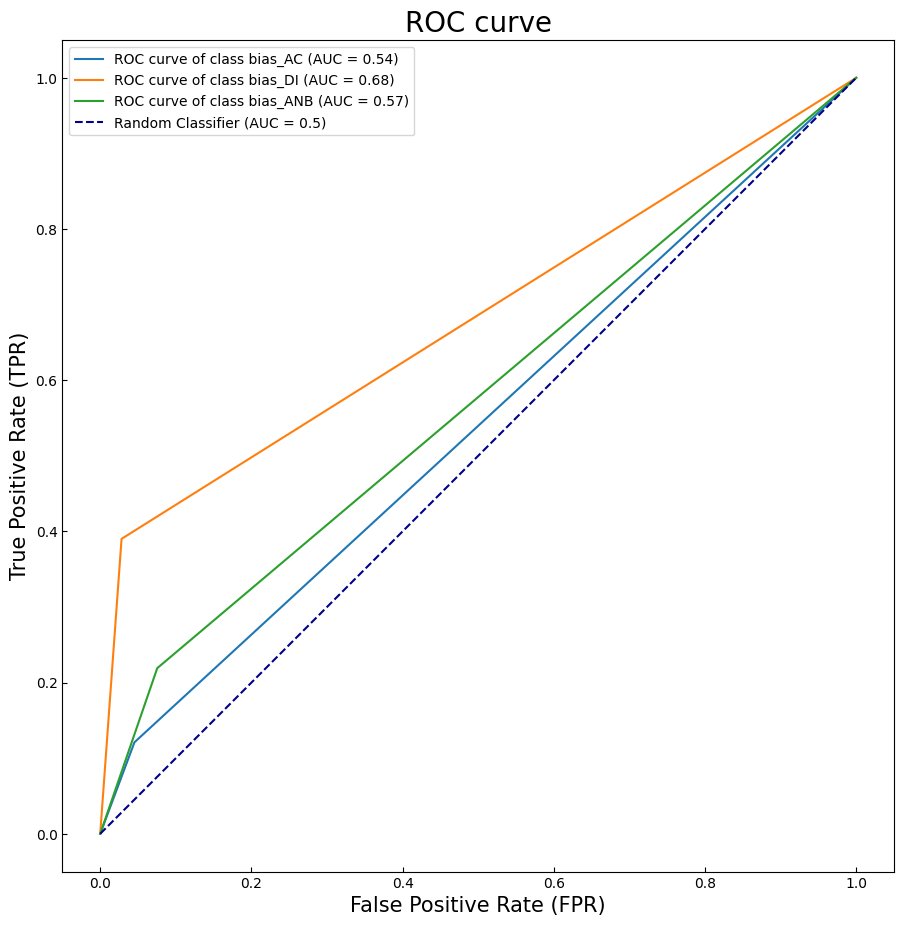

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
fig = plt.figure(figsize = (10.8, 10.8))
for i in range(len(labels)):
  y_true = [label[i] for label in test["bias_labels"].tolist()]
  y_pred = [label[i] for label in test["predicted_labels"].tolist()]
  fpr, tpr, _ = roc_curve(y_true, y_pred)
  plt.plot(fpr, tpr, label="ROC curve of class {} (AUC = {:0.2f})".format(labels[i], auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], "k--", color = "darkblue", linestyle = "--", label = "Random Classifier (AUC = 0.5)") # AUC: Area Under Curve
plt.axis("square")
plt.xlabel("False Positive Rate (FPR)", fontsize = 15)
plt.ylabel("True Positive Rate (TPR)", fontsize = 15)
plt.title("ROC curve", fontsize = 20)
plt.tick_params(axis = "y",direction = "in")
plt.tick_params(axis = "x",direction = "in")
plt.legend()
plt.show()

# test

best_ensemble: max weighted_f1  

In [23]:
test = pd.DataFrame(load_dataset("public_data/train/track_a/eng_test", split="test"))

In [29]:
# f1_scores = {ensemble_name: ensembles[ensemble_name]["metrics"].get("weighted_f1") for ensemble_name in ensemble_evaluation}
# best_ensemble_name = max(f1_scores, key=f1_scores.get)
best_ensemble_name = 'ensemble00'
best_ensemble = {"name": best_ensemble_name,                 
"models": ensembles[best_ensemble_name].get("models"),                 
"metrics": ensembles[best_ensemble_name].get("metrics")                 
}
best_ensemble

{'name': 'ensemble00',
 'models': ['bert-cased'],
 'metrics': {'accuracy': 0.53585,
  'macro_f1': 0.2701,
  'macro_precision': 0.46676,
  'macro_recall': 0.21519,
  'weighted_f1': 0.23306}}

In [30]:
for model_name in best_ensemble.get("models"):
  model_predictions, model_raw_outputs = models.get(model_name).predict(test["ori_sentence"].tolist())
  model_evaluation[model_name]["test_model_outputs"] = model_raw_outputs
  model_evaluation[model_name]["test_predictions"] = list ()  
  for output in model_raw_outputs:
    model_evaluation[model_name]["test_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output])
predict_ensemble(best_ensemble.get("name"), "test", test, weighted=WEIGHTED)

1it [00:02,  2.55s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 40.20it/s]


In [31]:
test["bias_labels"] = ensemble_evaluation[best_ensemble.get("name")].get("test_predictions")
test.head(10)

,ori_sentence,bias_labels
0,霍尊称自己是“极端主义”，认为女人就该有女人的样子，不然“会把她打死”，并称“我断定我肯定会...,"[0, 0, 1]"
1,文案职位仅招男性，因为需要出差。,"[0, 0, 0]"
2,好像所有女人在工作之前都得变美，一个女人打扮是肤浅，而不打扮是没礼貌。,"[0, 0, 0]"
3,如果第一个登上月球的是女性，她可能也要穿高跟鞋。,"[0, 0, 0]"
4,受传统观念和生理条件影响，育儿和承担家庭责任被视为女性天职。,"[0, 0, 0]"
5,授课人莫兰说，大自然给了男性接受外部挑战的理想条件，所以男人要在社会、家庭生活中担任好“领导...,"[0, 0, 0]"
6,中国女人挑选男人的标准是男人要会赚钱，至于良心好不好不管，所以中国女性的堕落导致了国家的堕落。,"[1, 0, 0]"
7,一开学术会议，男博士们都在研究课题，女博士则聊多大生小孩，痛诉“血泪史”。,"[0, 0, 0]"
8,比起男人和男孩之间的轻易合作，女性之间更容易在社交场合出现相互排挤的现象。,"[0, 0, 0]"
9,戏剧故事中，女性过了30岁就开始不为自己而活，或是围绕儿女做个讨人嫌的母亲（这样还能有点存在...,"[0, 0, 0]"


In [32]:
best_ensemble.get("models")[0]

'bert-cased'

In [33]:
test.to_csv(f"chinese_test_submission_{best_ensemble.get('models')[0]}.csv",index = False)

best_ensemble: max macro_precision

In [34]:
# f1_scores = {ensemble_name: ensembles[ensemble_name]["metrics"].get("macro_precision") for ensemble_name in ensemble_evaluation}
# best_ensemble_name = max(f1_scores, key=f1_scores.get)
best_ensemble_name = 'ensemble11'
best_ensemble = {"name": best_ensemble_name,                 
"models": ensembles[best_ensemble_name].get("models"),                 
"metrics": ensembles[best_ensemble_name].get("metrics")                 
}
best_ensemble

{'name': 'ensemble11',
 'models': ['bert-cased', 'ernie-base', 'roberta-chinese-large'],
 'metrics': {'accuracy': 0.52519,
  'macro_f1': 0.25218,
  'macro_precision': 0.39998,
  'macro_recall': 0.18498,
  'weighted_f1': 0.21615}}

In [35]:
for model_name in best_ensemble.get("models"):
  model_predictions, model_raw_outputs = models.get(model_name).predict(test["ori_sentence"].tolist())
  model_evaluation[model_name]["test_model_outputs"] = model_raw_outputs
  model_evaluation[model_name]["test_predictions"] = list ()  
  for output in model_raw_outputs:
    model_evaluation[model_name]["test_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output])
predict_ensemble(best_ensemble.get("name"), "test", test, weighted=WEIGHTED)

1it [00:02,  2.72s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 36.19it/s]
1it [00:02,  2.56s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 38.90it/s]
1it [00:02,  2.52s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:01<00:00, 24.02it/s]


In [36]:
test["bias_labels"] = ensemble_evaluation[best_ensemble.get("name")].get("test_predictions")
test.head(10)

,ori_sentence,bias_labels
0,霍尊称自己是“极端主义”，认为女人就该有女人的样子，不然“会把她打死”，并称“我断定我肯定会...,"[0, 0, 1]"
1,文案职位仅招男性，因为需要出差。,"[0, 0, 0]"
2,好像所有女人在工作之前都得变美，一个女人打扮是肤浅，而不打扮是没礼貌。,"[0, 0, 0]"
3,如果第一个登上月球的是女性，她可能也要穿高跟鞋。,"[0, 0, 0]"
4,受传统观念和生理条件影响，育儿和承担家庭责任被视为女性天职。,"[0, 0, 0]"
5,授课人莫兰说，大自然给了男性接受外部挑战的理想条件，所以男人要在社会、家庭生活中担任好“领导...,"[0, 0, 0]"
6,中国女人挑选男人的标准是男人要会赚钱，至于良心好不好不管，所以中国女性的堕落导致了国家的堕落。,"[0, 0, 0]"
7,一开学术会议，男博士们都在研究课题，女博士则聊多大生小孩，痛诉“血泪史”。,"[0, 0, 0]"
8,比起男人和男孩之间的轻易合作，女性之间更容易在社交场合出现相互排挤的现象。,"[0, 0, 0]"
9,戏剧故事中，女性过了30岁就开始不为自己而活，或是围绕儿女做个讨人嫌的母亲（这样还能有点存在...,"[0, 0, 0]"


In [37]:
best_ensemble.get("models")[0]+'--'+best_ensemble.get("models")[1]+'--'+best_ensemble.get("models")[2]

'bert-cased--ernie-base--roberta-chinese-large'

In [38]:
test.to_csv(f"chinese_test_submission_{best_ensemble.get('models')[0]+'--'+best_ensemble.get('models')[1]+'--'+best_ensemble.get('models')[2]}.csv",index = False)

best_ensemble: ensemble14	 

In [39]:
best_ensemble_name = 'ensemble14'
best_ensemble = {"name": best_ensemble_name,                 
"models": ensembles[best_ensemble_name].get("models"),                 
"metrics": ensembles[best_ensemble_name].get("metrics")                 
}
best_ensemble

{'name': 'ensemble14',
 'models': ['bert-cased',
  'ernie-base',
  'roberta-chinese',
  'roberta-chinese-large'],
 'metrics': {'accuracy': 0.52519,
  'macro_f1': 0.25218,
  'macro_precision': 0.39998,
  'macro_recall': 0.18498,
  'weighted_f1': 0.21615}}

In [40]:
for model_name in best_ensemble.get("models"):
  model_predictions, model_raw_outputs = models.get(model_name).predict(test["ori_sentence"].tolist())
  model_evaluation[model_name]["test_model_outputs"] = model_raw_outputs
  model_evaluation[model_name]["test_predictions"] = list ()  
  for output in model_raw_outputs:
    model_evaluation[model_name]["test_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output])
predict_ensemble(best_ensemble.get("name"), "test", test, weighted=WEIGHTED)

1it [00:02,  2.52s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 41.17it/s]
1it [00:02,  2.55s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 39.11it/s]
1it [00:02,  2.53s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:01<00:00, 23.49it/s]
1it [00:02,  2.52s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|

In [41]:
test["bias_labels"] = ensemble_evaluation[best_ensemble.get("name")].get("test_predictions")
test.head(10)

,ori_sentence,bias_labels
0,霍尊称自己是“极端主义”，认为女人就该有女人的样子，不然“会把她打死”，并称“我断定我肯定会...,"[0, 0, 1]"
1,文案职位仅招男性，因为需要出差。,"[0, 0, 0]"
2,好像所有女人在工作之前都得变美，一个女人打扮是肤浅，而不打扮是没礼貌。,"[0, 0, 0]"
3,如果第一个登上月球的是女性，她可能也要穿高跟鞋。,"[0, 0, 0]"
4,受传统观念和生理条件影响，育儿和承担家庭责任被视为女性天职。,"[0, 0, 0]"
5,授课人莫兰说，大自然给了男性接受外部挑战的理想条件，所以男人要在社会、家庭生活中担任好“领导...,"[0, 0, 0]"
6,中国女人挑选男人的标准是男人要会赚钱，至于良心好不好不管，所以中国女性的堕落导致了国家的堕落。,"[0, 0, 0]"
7,一开学术会议，男博士们都在研究课题，女博士则聊多大生小孩，痛诉“血泪史”。,"[0, 0, 0]"
8,比起男人和男孩之间的轻易合作，女性之间更容易在社交场合出现相互排挤的现象。,"[0, 0, 0]"
9,戏剧故事中，女性过了30岁就开始不为自己而活，或是围绕儿女做个讨人嫌的母亲（这样还能有点存在...,"[0, 0, 0]"


In [42]:
best_ensemble.get("models")[0]+'--'+best_ensemble.get("models")[1]+'--'+best_ensemble.get("models")[2]+'--'+best_ensemble.get("models")[3]

'bert-cased--ernie-base--roberta-chinese--roberta-chinese-large'

In [43]:
test.to_csv(f"chinese_test_submission_{best_ensemble.get('models')[0]+'--'+best_ensemble.get('models')[1]+'--'+best_ensemble.get('models')[2]+'--'+best_ensemble.get('models')[3]}.csv",index = False)